# Szdegmentaló ensemble notebook  
**Modellek:** U-Net+FNO, Attention U-Net+FNO, DeepLabV3+  


In [ ]:

# 0) Colab / package setup


try:
    import segmentation_models_pytorch as smp
except Exception:
    !pip -q install segmentation-models-pytorch

try:
    import albumentations as A
    from albumentations.pytorch import ToTensorV2
except Exception:
    !pip -q install albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.1 MB/s eta 0:00:00


In [ ]:


# 1) Imports

import os
import gc
import json
import time
import math
import random
from dataclasses import dataclass, asdict
from typing import Dict, Tuple, List, Optional

import numpy as np
import pandas as pd
from PIL import Image

import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

from tqdm.auto import tqdm

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

from sklearn.model_selection import train_test_split

try:
    from scipy.stats import wilcoxon
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("SMP:", smp.__version__)

Torch: 2.10.0+cu128
CUDA available: True
SMP: 0.5.0


In [ ]:
# 2) Google Drive mount

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

# 3) Config

@dataclass
class CFG:
    # --- dataset paths ---
    root_path: str = '/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/train'
    image_dir: str = '/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/train/images'
    mask_dir: str = '/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/train/masks'

    # --- checkpoints ---
    unet_ckpt: str = '/content/drive/MyDrive/Brain MRI/FNO_seg/Unet_FNO_2/models/unetfno_run1_best_model.pt'
    attunet_ckpt: str = '/content/drive/MyDrive/Brain MRI/FNO_seg/AttentionUnet_FNO/models/run1_att_fno_best_model.pt'
    deeplab_ckpt: str = '/content/drive/MyDrive/Brain MRI/FNO_seg/Deeplabv3plus/best_model.pt'

    # --- output ---
    output_dir: str = '/content/drive/MyDrive/Brain MRI/ensemble_publication_results_final'

    # --- reproducibility ---
    seed: int = 42

    # --- split ---
    val_ratio: float = 0.20

    # --- batch / loader ---
    batch_size: int = 4
    num_workers: int = 2
    pin_memory: bool = True

    # --- training image sizes used by original models ---
    unet_size: int = 256
    attunet_size: int = 256
    deeplab_size: int = 320

    # --- common evaluation size (all probabilities are resized here) ---
    eval_size: int = 320

    # --- model params ---
    in_channels: int = 1
    num_classes: int = 2
    fno_modes: int = 4

    # --- deeplab params from original training notebook ---
    deeplab_encoder_name: str = 'resnet34'
    deeplab_encoder_weights: Optional[str] = None  # load from checkpoint, not imagenet weights

    # --- inference ---
    device: str = 'cuda' if torch.cuda.is_available() else 'cpu'
    use_tta: bool = False
    save_probability_cache: bool = True

cfg = CFG()
os.makedirs(cfg.output_dir, exist_ok=True)
print(cfg)

CFG(root_path='/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/train', image_dir='/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/train/images', mask_dir='/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/train/masks', unet_ckpt='/content/drive/MyDrive/Brain MRI/FNO_seg/Unet_FNO_2/models/unetfno_run1_best_model.pt', attunet_ckpt='/content/drive/MyDrive/Brain MRI/FNO_seg/AttentionUnet_FNO/models/run1_att_fno_best_model.pt', deeplab_ckpt='/content/drive/MyDrive/Brain MRI/FNO_seg/Deeplabv3plus/best_model.pt', output_dir='/content/drive/MyDrive/Brain MRI/ensemble_publication_results_final', seed=42, val_ratio=0.2, batch_size=4, num_workers=2, pin_memory=True, unet_size=256, attunet_size=256, deeplab_size=320, eval_size=320, in_channels=1, num_classes=2, fno_modes=4, deeplab_encoder_name='resnet34', deeplab_encoder_weights=None, device='cuda', use_tta=False, save_probability_cache=True)


In [ ]:

# 4) Reproducibility

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(cfg.seed)

In [ ]:
# 5) Dataset utilities

VALID_EXTS = ('.png', '.jpg', '.jpeg', '.tif', '.tiff', '.bmp')

def list_image_files(folder: str):
    files = sorted([f for f in os.listdir(folder) if f.lower().endswith(VALID_EXTS)])
    if len(files) == 0:
        raise ValueError(f'Nincsenek képek itt: {folder}')
    return files

def infer_mask_filename(image_filename: str, available_masks: set):
    if image_filename in available_masks:
        return image_filename
    stem, _ = os.path.splitext(image_filename)
    for ext in ['.png', '.jpg', '.jpeg', '.tif', '.tiff', '.bmp']:
        cand = stem + ext
        if cand in available_masks:
            return cand
    raise FileNotFoundError(f'Nem találok maszkot ehhez a képhez: {image_filename}')

class RawSegmentationDataset(Dataset):
    """
    Nyers, grayscale képet és maszkot ad vissza numpy formában.
    A modellekhez szükséges resize/normalization később, modellenként történik.
    """
    def __init__(self, image_dir: str, mask_dir: str, filenames: List[str]):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.filenames = filenames
        self.available_masks = set(list_image_files(mask_dir))

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        image_name = self.filenames[idx]
        mask_name = infer_mask_filename(image_name, self.available_masks)

        image_path = os.path.join(self.image_dir, image_name)
        mask_path = os.path.join(self.mask_dir, mask_name)

        image = Image.open(image_path).convert('L')
        mask = Image.open(mask_path).convert('L')

        image_np = np.array(image, dtype=np.uint8)
        mask_np = np.array(mask, dtype=np.uint8)
        mask_np = (mask_np > 127).astype(np.uint8)

        return {
            'image': image_np,
            'mask': mask_np,
            'id': os.path.splitext(image_name)[0],
            'image_name': image_name,
            'mask_name': mask_name,
        }

def collate_raw(batch):
    return batch

In [ ]:

# 6) Split

all_images = list_image_files(cfg.image_dir)
train_files, val_files = train_test_split(
    all_images,
    test_size=cfg.val_ratio,
    random_state=cfg.seed,
    shuffle=True
)

val_dataset = RawSegmentationDataset(cfg.image_dir, cfg.mask_dir, val_files)
val_loader = DataLoader(
    val_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=cfg.pin_memory,
    collate_fn=collate_raw,
)

print(f"Összes kép: {len(all_images)}")
print(f"Validációs képek: {len(val_files)}")

Összes kép: 3933
Validációs képek: 787


In [ ]:
# 7) Model-specific preprocess

def preprocess_grayscale_numpy(image_np: np.ndarray, target_size: int, mean: float, std: float):
    image_resized = cv2.resize(image_np, (target_size, target_size), interpolation=cv2.INTER_LINEAR)
    image_resized = image_resized.astype(np.float32) / 255.0
    image_resized = (image_resized - mean) / std
    image_resized = np.expand_dims(image_resized, axis=0)  # (1,H,W)
    return torch.from_numpy(image_resized).float()

def preprocess_mask_numpy(mask_np: np.ndarray, target_size: int):
    mask_resized = cv2.resize(mask_np.astype(np.uint8), (target_size, target_size), interpolation=cv2.INTER_NEAREST)
    return torch.from_numpy(mask_resized.astype(np.int64))

# U-Net+FNO training preprocessing:
# image /255 only
def preprocess_unet(image_np):
    return preprocess_grayscale_numpy(image_np, cfg.unet_size, mean=0.0, std=1.0)

def preprocess_attunet(image_np):
    return preprocess_grayscale_numpy(image_np, cfg.attunet_size, mean=0.0, std=1.0)

# DeepLab training preprocessing:
# A.Normalize(mean=(0.5,), std=(0.5,))
def preprocess_deeplab(image_np):
    return preprocess_grayscale_numpy(image_np, cfg.deeplab_size, mean=0.5, std=0.5)

def preprocess_mask_eval(mask_np):
    return preprocess_mask_numpy(mask_np, cfg.eval_size)

In [ ]:
# 8) Metrics

def dice_binary_from_masks(pred_mask: np.ndarray, true_mask: np.ndarray, eps: float = 1e-7):
    pred_mask = pred_mask.astype(np.uint8)
    true_mask = true_mask.astype(np.uint8)
    intersection = (pred_mask * true_mask).sum()
    return (2.0 * intersection + eps) / (pred_mask.sum() + true_mask.sum() + eps)

def iou_binary_from_masks(pred_mask: np.ndarray, true_mask: np.ndarray, eps: float = 1e-7):
    pred_mask = pred_mask.astype(np.uint8)
    true_mask = true_mask.astype(np.uint8)
    intersection = (pred_mask * true_mask).sum()
    union = pred_mask.sum() + true_mask.sum() - intersection
    return (intersection + eps) / (union + eps)

def compute_case_metrics(pred_mask: np.ndarray, true_mask: np.ndarray):
    dice = dice_binary_from_masks(pred_mask, true_mask)
    iou = iou_binary_from_masks(pred_mask, true_mask)
    return {'dice': float(dice), 'iou': float(iou)}

def bootstrap_ci(values, n_boot=2000, alpha=0.05, seed=42):
    values = np.asarray(values, dtype=np.float64)
    rng = np.random.default_rng(seed)
    means = []
    n = len(values)
    for _ in range(n_boot):
        sample = rng.choice(values, size=n, replace=True)
        means.append(sample.mean())
    lo = np.percentile(means, 100 * (alpha / 2))
    hi = np.percentile(means, 100 * (1 - alpha / 2))
    return float(lo), float(hi)

In [ ]:


# 9) Checkpoint-compatible model definitions
#    (exactly matching the FNO training notebooks)

@torch.jit.script
def compl_mul2d(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    return torch.einsum("bixy, ioxy->boxy", a, b)

class SpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2
        self.scale = 1 / (in_channels * out_channels)
        self.weights1 = nn.Parameter(
            self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, dtype=torch.cfloat)
        )
        self.weights2 = nn.Parameter(
            self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, dtype=torch.cfloat)
        )

    def forward(self, x):
        batchsize = x.shape[0]
        x_ft = torch.fft.rfftn(x, dim=[2, 3])

        out_ft = torch.zeros(
            batchsize,
            self.out_channels,
            x.size(-2),
            x.size(-1) // 2 + 1,
            device=x.device,
            dtype=torch.cfloat
        )

        out_ft[:, :, :self.modes1, :self.modes2] = compl_mul2d(
            x_ft[:, :, :self.modes1, :self.modes2], self.weights1
        )
        out_ft[:, :, -self.modes1:, :self.modes2] = compl_mul2d(
            x_ft[:, :, -self.modes1:, :self.modes2], self.weights2
        )

        x = torch.fft.irfftn(out_ft, s=(x.size(-2), x.size(-1)), dim=[2, 3])
        return x

class FourierLayer(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1, modes=4):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
            bias=True
        )
        self.conv_fno = SpectralConv2d(in_channels, out_channels, modes, modes)

    def forward(self, x):
        x1 = self.conv(x)
        x2 = self.conv_fno(x)
        return x1 + x2

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch, modes=4):
        super().__init__()
        self.net = nn.Sequential(
            FourierLayer(in_ch, out_ch, kernel_size=3, stride=1, padding=1, modes=modes),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            FourierLayer(out_ch, out_ch, kernel_size=3, stride=1, padding=1, modes=modes),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)

class UNetFNO(nn.Module):
    def __init__(self, in_channels=1, out_channels=2, modes=4):
        super().__init__()
        self.down1 = DoubleConv(in_channels, 64, modes=modes)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128, modes=modes)
        self.pool2 = nn.MaxPool2d(2)

        self.bridge = DoubleConv(128, 256, modes=modes)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv2 = DoubleConv(256, 128, modes=modes)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(128, 64, modes=modes)

        self.out_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        d1 = self.down1(x)
        p1 = self.pool1(d1)

        d2 = self.down2(p1)
        p2 = self.pool2(d2)

        b = self.bridge(p2)

        u2 = self.up2(b)
        u2 = torch.cat([u2, d2], dim=1)
        u2 = self.conv2(u2)

        u1 = self.up1(u2)
        u1 = torch.cat([u1, d1], dim=1)
        u1 = self.conv1(u1)

        out = self.out_conv(u1)
        return out

class AttentionBlock(nn.Module):
    def __init__(self, g_ch, x_ch, inter_ch):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(g_ch, inter_ch, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(inter_ch),
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(x_ch, inter_ch, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(inter_ch),
        )
        self.psi = nn.Sequential(
            nn.Conv2d(inter_ch, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid(),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

class AttentionUNetFNO(nn.Module):
    def __init__(self, in_channels=1, out_channels=2, modes=4):
        super().__init__()
        self.down1 = DoubleConv(in_channels, 64, modes=modes)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128, modes=modes)
        self.pool2 = nn.MaxPool2d(2)

        self.bridge = DoubleConv(128, 256, modes=modes)

        self.att2 = AttentionBlock(g_ch=128, x_ch=128, inter_ch=64)
        self.att1 = AttentionBlock(g_ch=64, x_ch=64, inter_ch=32)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv2 = DoubleConv(256, 128, modes=modes)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(128, 64, modes=modes)

        self.out_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        d1 = self.down1(x)
        p1 = self.pool1(d1)

        d2 = self.down2(p1)
        p2 = self.pool2(d2)

        b = self.bridge(p2)

        u2 = self.up2(b)
        d2_att = self.att2(g=u2, x=d2)
        u2 = torch.cat([u2, d2_att], dim=1)
        u2 = self.conv2(u2)

        u1 = self.up1(u2)
        d1_att = self.att1(g=u1, x=d1)
        u1 = torch.cat([u1, d1_att], dim=1)
        u1 = self.conv1(u1)

        out = self.out_conv(u1)
        return out

def build_deeplab():
    model = smp.DeepLabV3Plus(
        encoder_name=cfg.deeplab_encoder_name,
        encoder_weights=cfg.deeplab_encoder_weights,
        in_channels=cfg.in_channels,
        classes=cfg.num_classes,
        activation=None,
    )
    return model

In [ ]:


# 10) Robust checkpoint loading

def extract_state_dict(ckpt_obj):
    if isinstance(ckpt_obj, dict):
        for key in ['model_state_dict', 'state_dict', 'model', 'net']:
            if key in ckpt_obj and isinstance(ckpt_obj[key], dict):
                return ckpt_obj[key]
    if isinstance(ckpt_obj, dict):
        return ckpt_obj
    raise ValueError('Ismeretlen checkpoint formátum.')

def strip_module_prefix(state_dict):
    if all(k.startswith('module.') for k in state_dict.keys()):
        return {k.replace('module.', '', 1): v for k, v in state_dict.items()}
    return state_dict

def load_checkpoint_to_model(model, ckpt_path, device):
    print(f'Checkpoint betöltése: {ckpt_path}')
    ckpt = torch.load(ckpt_path, map_location=device)
    state_dict = extract_state_dict(ckpt)
    state_dict = strip_module_prefix(state_dict)
    missing, unexpected = model.load_state_dict(state_dict, strict=True)
    print('Missing keys:', missing)
    print('Unexpected keys:', unexpected)
    model.to(device)
    model.eval()
    return model, ckpt

unet_model = UNetFNO(in_channels=1, out_channels=2, modes=cfg.fno_modes)
attunet_model = AttentionUNetFNO(in_channels=1, out_channels=2, modes=cfg.fno_modes)
deeplab_model = build_deeplab()

unet_model, unet_ckpt_obj = load_checkpoint_to_model(unet_model, cfg.unet_ckpt, cfg.device)
attunet_model, att_ckpt_obj = load_checkpoint_to_model(attunet_model, cfg.attunet_ckpt, cfg.device)
deeplab_model, deeplab_ckpt_obj = load_checkpoint_to_model(deeplab_model, cfg.deeplab_ckpt, cfg.device)

print('Mindhárom modell sikeresen betöltve.')

Checkpoint betöltése: /content/drive/MyDrive/Brain MRI/FNO_seg/Unet_FNO_2/models/unetfno_run1_best_model.pt
Missing keys: []
Unexpected keys: []
Checkpoint betöltése: /content/drive/MyDrive/Brain MRI/FNO_seg/AttentionUnet_FNO/models/run1_att_fno_best_model.pt
Missing keys: []
Unexpected keys: []
Checkpoint betöltése: /content/drive/MyDrive/Brain MRI/FNO_seg/Deeplabv3plus/best_model.pt
Missing keys: []
Unexpected keys: []
Mindhárom modell sikeresen betöltve.


In [ ]:


# 11) Inference helpers

def resize_probs_to_eval_size(probs: torch.Tensor, eval_size: int):
    # probs: [B, C, H, W]
    return F.interpolate(probs, size=(eval_size, eval_size), mode='bilinear', align_corners=False)

@torch.no_grad()
def predict_probs_single(model, image_tensor: torch.Tensor, device: str, eval_size: int):
    """
    image_tensor: [1,1,H,W] already preprocessed for the given model
    returns probs resized to common eval size: [1,2,eval_size,eval_size]
    """
    image_tensor = image_tensor.to(device)
    logits = model(image_tensor)
    probs = torch.softmax(logits, dim=1)
    probs = resize_probs_to_eval_size(probs, eval_size)
    return probs

@torch.no_grad()
def predict_probs_single_tta(model, image_tensor: torch.Tensor, device: str, eval_size: int):
    """
    Egyszerű TTA: original + hflip + vflip.
    """
    image_tensor = image_tensor.to(device)

    probs_all = []

    # original
    logits = model(image_tensor)
    probs_all.append(torch.softmax(logits, dim=1))

    # hflip
    x = torch.flip(image_tensor, dims=[3])
    logits = model(x)
    probs = torch.softmax(logits, dim=1)
    probs = torch.flip(probs, dims=[3])
    probs_all.append(probs)

    # vflip
    x = torch.flip(image_tensor, dims=[2])
    logits = model(x)
    probs = torch.softmax(logits, dim=1)
    probs = torch.flip(probs, dims=[2])
    probs_all.append(probs)

    probs = torch.stack(probs_all, dim=0).mean(dim=0)
    probs = resize_probs_to_eval_size(probs, eval_size)
    return probs

def model_predict_probs(model_name: str, image_np: np.ndarray):
    if model_name == 'unet_fno':
        x = preprocess_unet(image_np).unsqueeze(0)
        fn = predict_probs_single_tta if cfg.use_tta else predict_probs_single
        return fn(unet_model, x, cfg.device, cfg.eval_size)
    elif model_name == 'attunet_fno':
        x = preprocess_attunet(image_np).unsqueeze(0)
        fn = predict_probs_single_tta if cfg.use_tta else predict_probs_single
        return fn(attunet_model, x, cfg.device, cfg.eval_size)
    elif model_name == 'deeplabv3plus':
        x = preprocess_deeplab(image_np).unsqueeze(0)
        fn = predict_probs_single_tta if cfg.use_tta else predict_probs_single
        return fn(deeplab_model, x, cfg.device, cfg.eval_size)
    else:
        raise ValueError(model_name)

In [ ]:

# 12) Sanity check

sample = val_dataset[0]
sample_img = sample['image']
sample_mask = sample['mask']

p_unet = model_predict_probs('unet_fno', sample_img)
p_att = model_predict_probs('attunet_fno', sample_img)
p_deep = model_predict_probs('deeplabv3plus', sample_img)

print('U-Net probs shape:', tuple(p_unet.shape), 'range:', float(p_unet.min()), float(p_unet.max()))
print('Att U-Net probs shape:', tuple(p_att.shape), 'range:', float(p_att.min()), float(p_att.max()))
print('DeepLab probs shape:', tuple(p_deep.shape), 'range:', float(p_deep.min()), float(p_deep.max()))

pred_unet = torch.argmax(p_unet, dim=1).squeeze(0).cpu().numpy()
pred_att = torch.argmax(p_att, dim=1).squeeze(0).cpu().numpy()
pred_deep = torch.argmax(p_deep, dim=1).squeeze(0).cpu().numpy()
gt_eval = preprocess_mask_eval(sample_mask).numpy()

print('GT unique:', np.unique(gt_eval))
print('U-Net pred unique:', np.unique(pred_unet))
print('Att pred unique:', np.unique(pred_att))
print('DeepLab pred unique:', np.unique(pred_deep))

U-Net probs shape: (1, 2, 320, 320) range: 0.0 1.0
Att U-Net probs shape: (1, 2, 320, 320) range: 0.0 1.0
DeepLab probs shape: (1, 2, 320, 320) range: 8.899377762494609e-12 1.0
GT unique: [0 1]
U-Net pred unique: [0 1]
Att pred unique: [0 1]
DeepLab pred unique: [0 1]


In [ ]:
# 13) Evaluation core

def evaluate_model_or_ensemble(
    val_loader,
    mode: str,
    weights: Tuple[float, float, float] = (1/3, 1/3, 1/3),
    save_prob_cache: bool = True,
):
    assert mode in ['unet_fno', 'attunet_fno', 'deeplabv3plus', 'equal_ensemble', 'weighted_ensemble']

    rows = []
    prob_cache = {} if save_prob_cache else None

    for batch in tqdm(val_loader, desc=f'Evaluating: {mode}'):
        for item in batch:
            image_np = item['image']
            mask_np = item['mask']
            case_id = item['id']

            gt_eval = preprocess_mask_eval(mask_np).numpy()

            p1 = model_predict_probs('unet_fno', image_np)
            p2 = model_predict_probs('attunet_fno', image_np)
            p3 = model_predict_probs('deeplabv3plus', image_np)

            if mode == 'unet_fno':
                probs = p1
            elif mode == 'attunet_fno':
                probs = p2
            elif mode == 'deeplabv3plus':
                probs = p3
            elif mode == 'equal_ensemble':
                probs = (p1 + p2 + p3) / 3.0
            elif mode == 'weighted_ensemble':
                w1, w2, w3 = weights
                probs = w1 * p1 + w2 * p2 + w3 * p3

            pred = torch.argmax(probs, dim=1).squeeze(0).cpu().numpy().astype(np.uint8)
            metrics = compute_case_metrics(pred, gt_eval)

            row = {
                'id': case_id,
                'dice': metrics['dice'],
                'iou': metrics['iou'],
            }
            rows.append(row)

            if save_prob_cache:
                prob_cache[case_id] = {
                    'unet_fno': p1.squeeze(0).cpu().numpy(),
                    'attunet_fno': p2.squeeze(0).cpu().numpy(),
                    'deeplabv3plus': p3.squeeze(0).cpu().numpy(),
                    'gt': gt_eval.astype(np.uint8),
                }

    df = pd.DataFrame(rows).sort_values('id').reset_index(drop=True)
    return df, prob_cache

In [ ]:
# 14) Single-model evaluation

single_results = {}
single_prob_caches = {}

for name in ['unet_fno', 'attunet_fno', 'deeplabv3plus']:
    df, cache = evaluate_model_or_ensemble(
        val_loader=val_loader,
        mode=name,
        save_prob_cache=cfg.save_probability_cache
    )
    single_results[name] = df
    single_prob_caches[name] = cache
    df.to_csv(os.path.join(cfg.output_dir, f'{name}_metrics.csv'), index=False)
    print(name, 'Dice mean:', round(df['dice'].mean(), 4), '| IoU mean:', round(df['iou'].mean(), 4))

Evaluating: unet_fno:   0%|          | 0/197 [00:00<?, ?it/s]

unet_fno Dice mean: 0.9184 | IoU mean: 0.8623


Evaluating: attunet_fno:   0%|          | 0/197 [00:00<?, ?it/s]

attunet_fno Dice mean: 0.92 | IoU mean: 0.8649


Evaluating: deeplabv3plus:   0%|          | 0/197 [00:00<?, ?it/s]

deeplabv3plus Dice mean: 0.8585 | IoU mean: 0.7771


In [ ]:


# 15) Weight search for weighted soft voting

def generate_weight_grid(step=0.05):
    weights = []
    vals = np.arange(0.0, 1.0 + 1e-9, step)
    for w1 in vals:
        for w2 in vals:
            w3 = 1.0 - w1 - w2
            if w3 < -1e-9:
                continue
            if w3 < 0:
                w3 = 0.0
            if abs((w1 + w2 + w3) - 1.0) < 1e-6:
                weights.append((round(float(w1), 4), round(float(w2), 4), round(float(w3), 4)))
    return weights

# Reuse cached probs from one of the single evaluations
reference_cache = next(iter(single_prob_caches.values()))

def score_weights_from_cache(prob_cache, weights):
    rows = []
    w1, w2, w3 = weights
    for case_id, item in prob_cache.items():
        p1 = torch.from_numpy(item['unet_fno']).unsqueeze(0)
        p2 = torch.from_numpy(item['attunet_fno']).unsqueeze(0)
        p3 = torch.from_numpy(item['deeplabv3plus']).unsqueeze(0)
        gt = item['gt']

        probs = w1 * p1 + w2 * p2 + w3 * p3
        pred = torch.argmax(probs, dim=1).squeeze(0).numpy().astype(np.uint8)
        metrics = compute_case_metrics(pred, gt)
        rows.append(metrics['dice'])
    return float(np.mean(rows))

weight_candidates = generate_weight_grid(step=0.05)
best_weights = None
best_score = -1.0

for w in tqdm(weight_candidates, desc='Searching weights'):
    score = score_weights_from_cache(reference_cache, w)
    if score > best_score:
        best_score = score
        best_weights = w

print('Best weights (U-Net, AttU-Net, DeepLab):', best_weights)
print('Best validation Dice:', round(best_score, 4))

Searching weights:   0%|          | 0/231 [00:00<?, ?it/s]

Best weights (U-Net, AttU-Net, DeepLab): (0.2, 0.45, 0.35)
Best validation Dice: 0.9251


In [ ]:


# 16) Ensemble evaluation

equal_df, equal_cache = evaluate_model_or_ensemble(
    val_loader=val_loader,
    mode='equal_ensemble',
    save_prob_cache=False
)

weighted_df, weighted_cache = evaluate_model_or_ensemble(
    val_loader=val_loader,
    mode='weighted_ensemble',
    weights=best_weights,
    save_prob_cache=False
)

equal_df.to_csv(os.path.join(cfg.output_dir, 'equal_ensemble_metrics.csv'), index=False)
weighted_df.to_csv(os.path.join(cfg.output_dir, 'weighted_ensemble_metrics.csv'), index=False)

print('equal_ensemble Dice mean:', round(equal_df['dice'].mean(), 4), '| IoU mean:', round(equal_df['iou'].mean(), 4))
print('weighted_ensemble Dice mean:', round(weighted_df['dice'].mean(), 4), '| IoU mean:', round(weighted_df['iou'].mean(), 4))

Evaluating: equal_ensemble:   0%|          | 0/197 [00:10<?, ?it/s]

Evaluating: weighted_ensemble:   0%|          | 0/197 [00:00<?, ?it/s]

equal_ensemble Dice mean: 0.9249 | IoU mean: 0.872
weighted_ensemble Dice mean: 0.9251 | IoU mean: 0.8722


In [ ]:

# 17) Publication table + confidence intervals

all_tables = {
    'unet_fno': single_results['unet_fno'],
    'attunet_fno': single_results['attunet_fno'],
    'deeplabv3plus': single_results['deeplabv3plus'],
    'equal_ensemble': equal_df,
    'weighted_ensemble': weighted_df,
}

summary_rows = []
for name, df in all_tables.items():
    dice_mean = df['dice'].mean()
    iou_mean = df['iou'].mean()
    dice_std = df['dice'].std(ddof=1)
    iou_std = df['iou'].std(ddof=1)
    dice_ci = bootstrap_ci(df['dice'].values)
    iou_ci = bootstrap_ci(df['iou'].values)
    summary_rows.append({
        'model': name,
        'dice_mean': dice_mean,
        'dice_std': dice_std,
        'dice_ci95_low': dice_ci[0],
        'dice_ci95_high': dice_ci[1],
        'iou_mean': iou_mean,
        'iou_std': iou_std,
        'iou_ci95_low': iou_ci[0],
        'iou_ci95_high': iou_ci[1],
    })

summary_df = pd.DataFrame(summary_rows).sort_values('dice_mean', ascending=False).reset_index(drop=True)
summary_df.to_csv(os.path.join(cfg.output_dir, 'publication_summary_table.csv'), index=False)
summary_df

,model,dice_mean,dice_std,dice_ci95_low,dice_ci95_high,iou_mean,iou_std,iou_ci95_low,iou_ci95_high
0,weighted_ensemble,0.925099,0.105979,0.917303,0.932097,0.872212,0.120389,0.863661,0.880307
1,equal_ensemble,0.924865,0.106926,0.917147,0.931840,0.871990,0.121209,0.863250,0.880175
2,attunet_fno,0.919980,0.113275,0.911892,0.927509,0.864877,0.127699,0.855938,0.873596
3,unet_fno,0.918419,0.113177,0.910407,0.925951,0.862302,0.128547,0.853260,0.871293
4,deeplabv3plus,0.858466,0.163334,0.846713,0.869444,0.777090,0.179715,0.764558,0.789137


In [ ]:


# 18) Optional statistical test

best_single_name = summary_df[summary_df['model'].isin(['unet_fno','attunet_fno','deeplabv3plus'])].iloc[0]['model']
best_single_df = all_tables[best_single_name].sort_values('id').reset_index(drop=True)
weighted_sorted = weighted_df.sort_values('id').reset_index(drop=True)

assert (best_single_df['id'].values == weighted_sorted['id'].values).all()

if SCIPY_AVAILABLE:
    stat, p_value = wilcoxon(weighted_sorted['dice'].values, best_single_df['dice'].values, alternative='greater')
    print(f'Wilcoxon signed-rank test | weighted_ensemble > {best_single_name}')
    print('statistic:', stat, 'p-value:', p_value)
    with open(os.path.join(cfg.output_dir, 'wilcoxon_test.txt'), 'w') as f:
        f.write(f'Best single model: {best_single_name}\n')
        f.write(f'Wilcoxon statistic: {stat}\n')
        f.write(f'p-value: {p_value}\n')
else:
    print('SciPy nincs telepítve, Wilcoxon teszt kihagyva.')

Wilcoxon signed-rank test | weighted_ensemble > attunet_fno
statistic: 216837.0 p-value: 7.778607899969375e-23


<Figure size 1000x500 with 0 Axes>

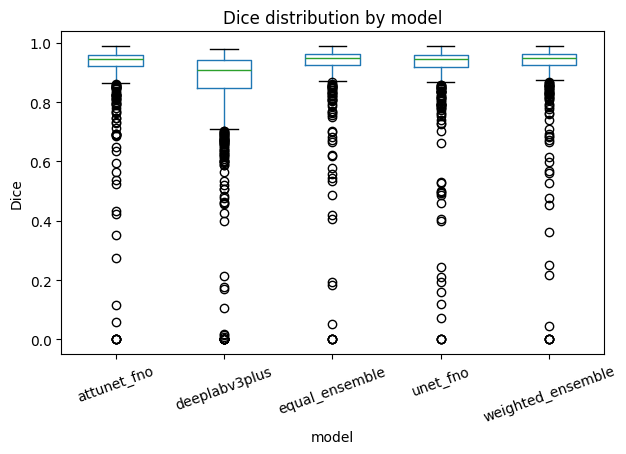

<Figure size 1000x500 with 0 Axes>

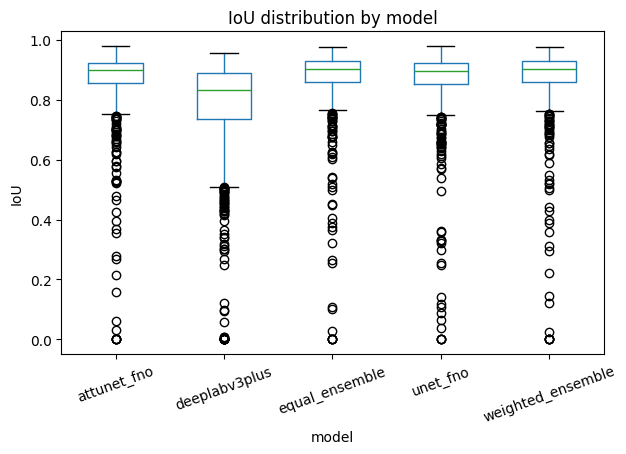

In [ ]:


# 19) Boxplot / performance plots

plot_df = []
for name, df in all_tables.items():
    temp = df.copy()
    temp['model'] = name
    plot_df.append(temp)
plot_df = pd.concat(plot_df, ignore_index=True)

plt.figure(figsize=(10, 5))
plot_df.boxplot(column='dice', by='model', grid=False, rot=20)
plt.title('Dice distribution by model')
plt.suptitle('')
plt.ylabel('Dice')
plt.tight_layout()
plt.savefig(os.path.join(cfg.output_dir, 'dice_boxplot.png'), dpi=200, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 5))
plot_df.boxplot(column='iou', by='model', grid=False, rot=20)
plt.title('IoU distribution by model')
plt.suptitle('')
plt.ylabel('IoU')
plt.tight_layout()
plt.savefig(os.path.join(cfg.output_dir, 'iou_boxplot.png'), dpi=200, bbox_inches='tight')
plt.show()

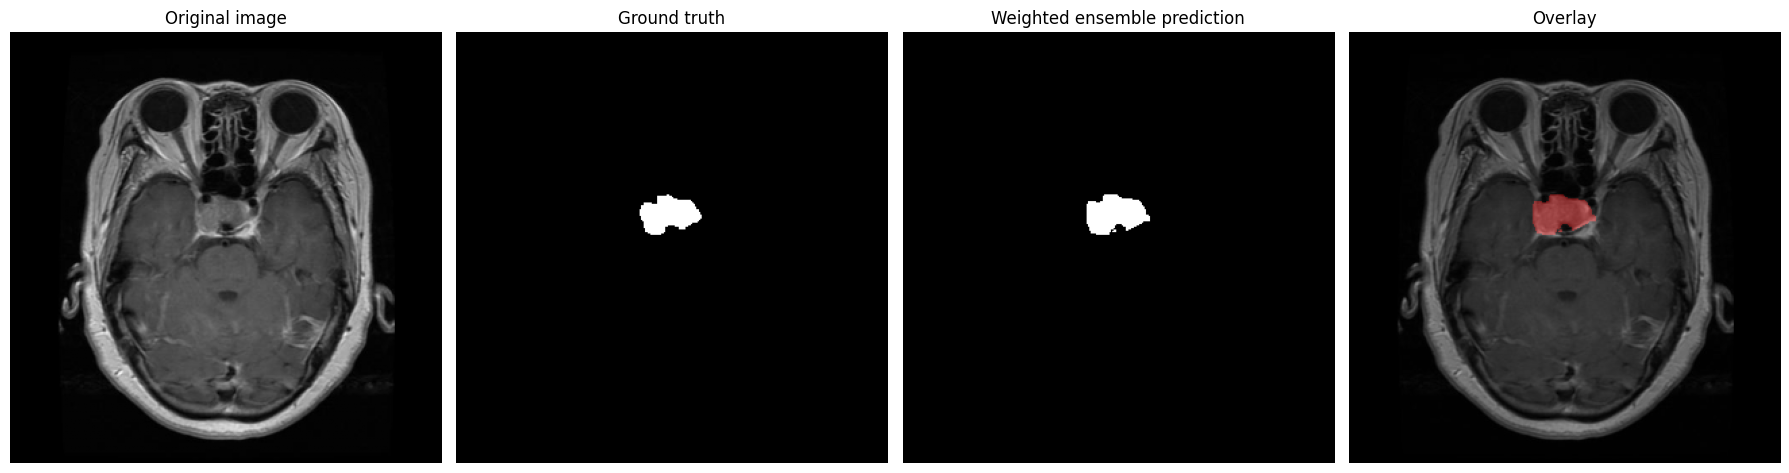

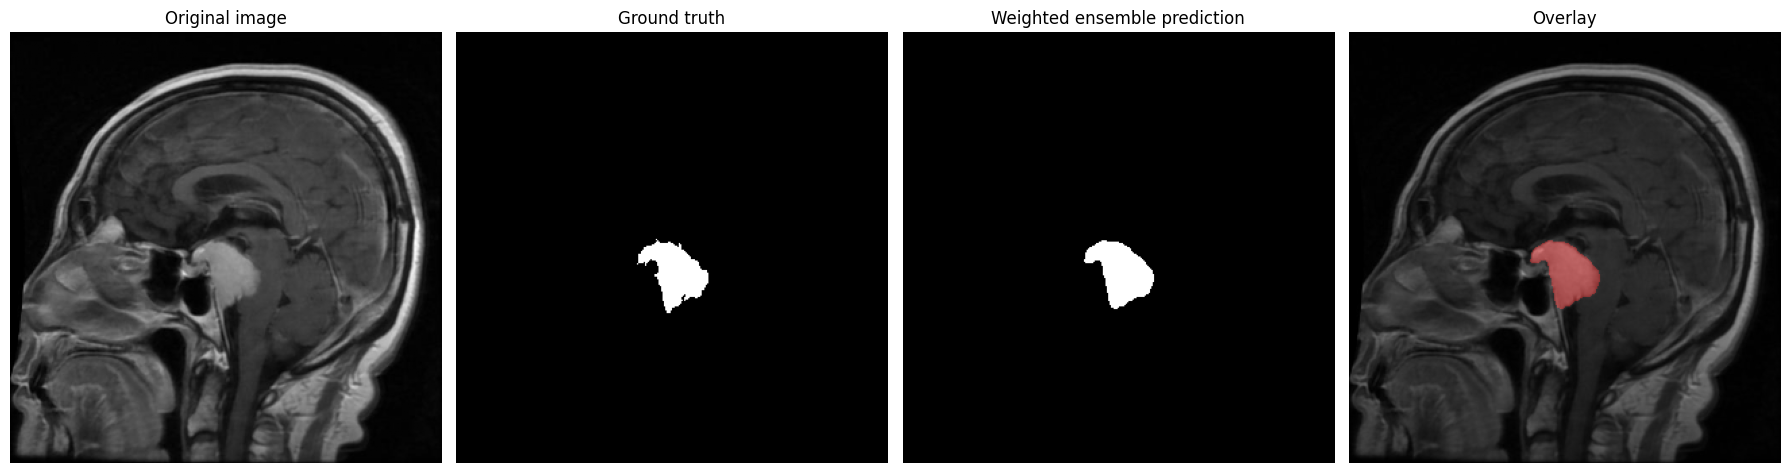

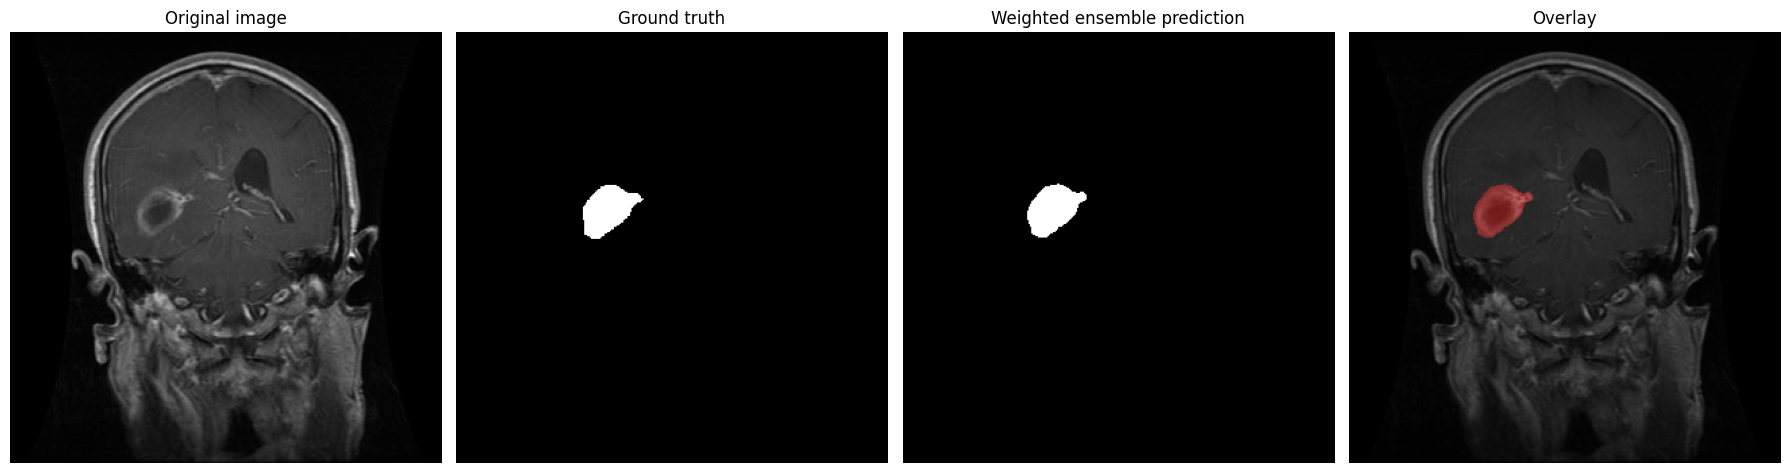

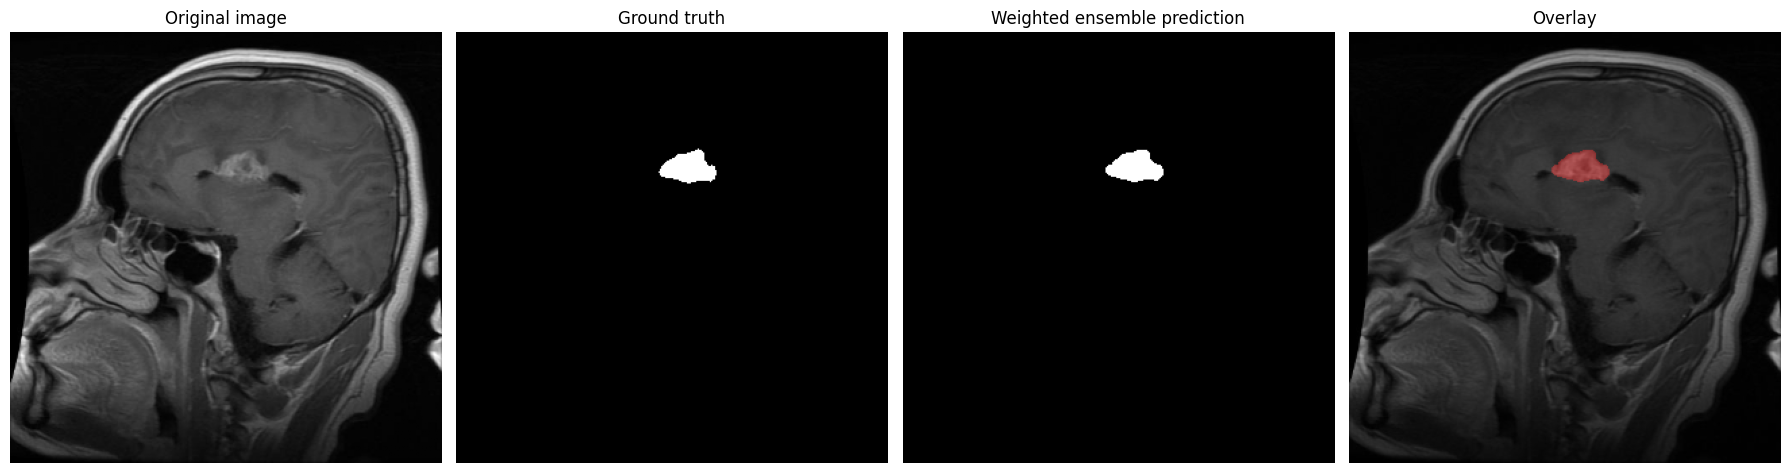

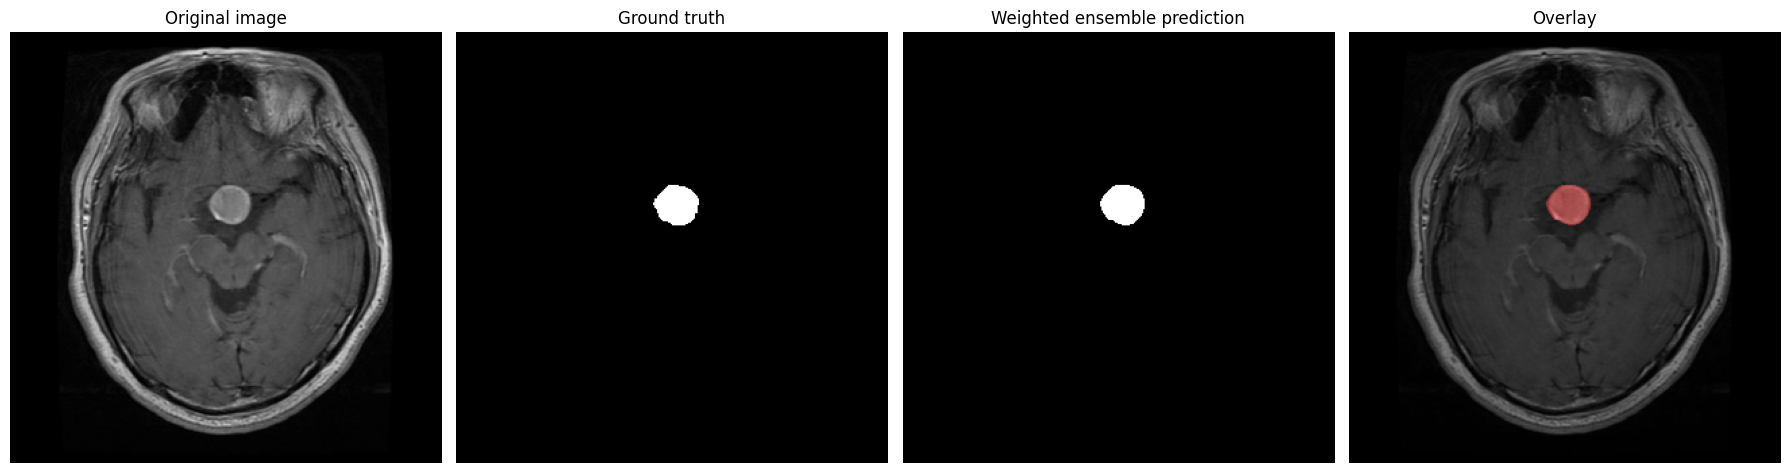

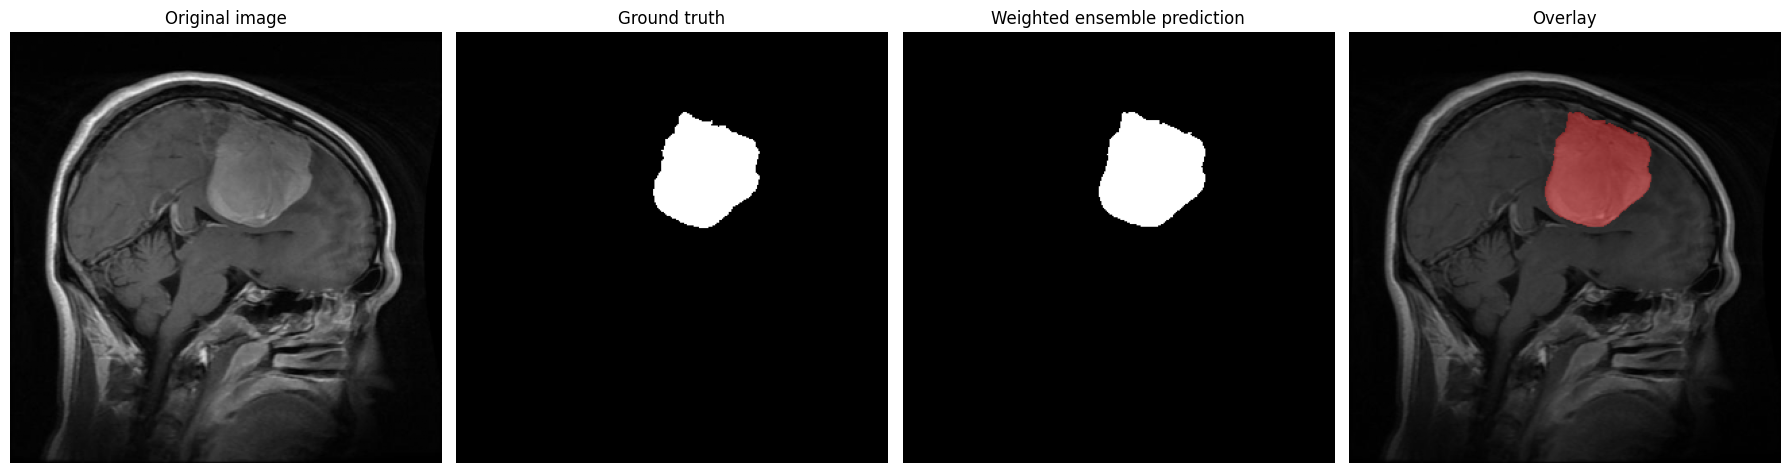

In [ ]:


# 20) Qualitative 4-column visualization

def denormalize_for_display(image_np: np.ndarray):
    # raw grayscale uint8 -> [0,1]
    img = image_np.astype(np.float32) / 255.0
    return img

def make_red_overlay(gray_img: np.ndarray, pred_mask: np.ndarray, alpha=0.35):
    gray = denormalize_for_display(gray_img)
    rgb = np.stack([gray, gray, gray], axis=-1)
    red = np.zeros_like(rgb)
    red[..., 0] = pred_mask.astype(np.float32)
    overlay = (1 - alpha) * rgb + alpha * red
    return np.clip(overlay, 0, 1)

def predict_weighted_ensemble_on_raw(image_np: np.ndarray, weights):
    p1 = model_predict_probs('unet_fno', image_np)
    p2 = model_predict_probs('attunet_fno', image_np)
    p3 = model_predict_probs('deeplabv3plus', image_np)
    w1, w2, w3 = weights
    probs = w1 * p1 + w2 * p2 + w3 * p3
    pred = torch.argmax(probs, dim=1).squeeze(0).cpu().numpy().astype(np.uint8)
    return pred, probs.squeeze(0).cpu().numpy()

def show_final_predictions_4cols(dataset, weights, num_samples=5, save_dir=None):
    rng = np.random.default_rng(cfg.seed)
    idxs = rng.choice(len(dataset), size=min(num_samples, len(dataset)), replace=False)

    for rank, idx in enumerate(idxs, start=1):
        item = dataset[idx]
        image_np = item['image']
        gt_eval = preprocess_mask_eval(item['mask']).numpy().astype(np.uint8)
        pred_mask, _ = predict_weighted_ensemble_on_raw(image_np, weights)
        image_eval = cv2.resize(image_np, (cfg.eval_size, cfg.eval_size), interpolation=cv2.INTER_LINEAR)

        overlay = make_red_overlay(image_eval, pred_mask)

        fig, axes = plt.subplots(1, 4, figsize=(18, 5))

        axes[0].imshow(image_eval, cmap='gray')
        axes[0].set_title('Original image')
        axes[0].axis('off')

        axes[1].imshow(gt_eval, cmap='gray')
        axes[1].set_title('Ground truth')
        axes[1].axis('off')

        axes[2].imshow(pred_mask, cmap='gray')
        axes[2].set_title('Weighted ensemble prediction')
        axes[2].axis('off')

        axes[3].imshow(overlay)
        axes[3].set_title('Overlay')
        axes[3].axis('off')

        plt.tight_layout()

        if save_dir is not None:
            os.makedirs(save_dir, exist_ok=True)
            out_path = os.path.join(save_dir, f'{rank:02d}_{item["id"]}_4col.png')
            plt.savefig(out_path, dpi=200, bbox_inches='tight')

        plt.show()

qual_dir = os.path.join(cfg.output_dir, 'qualitative_4col')
show_final_predictions_4cols(val_dataset, best_weights, num_samples=6, save_dir=qual_dir)

In [ ]:


# 21) Final save block

with open(os.path.join(cfg.output_dir, 'best_weights.json'), 'w') as f:
    json.dump({
        'weights': {
            'unet_fno': best_weights[0],
            'attunet_fno': best_weights[1],
            'deeplabv3plus': best_weights[2],
        },
        'use_tta': cfg.use_tta,
        'eval_size': cfg.eval_size,
    }, f, indent=2)

summary_df.to_json(os.path.join(cfg.output_dir, 'publication_summary_table.json'), orient='records', indent=2)

print('Minden fő eredmény elmentve ide:')
print(cfg.output_dir)
print('\nFájlok:')
for name in sorted(os.listdir(cfg.output_dir)):
    print('-', name)

Minden fő eredmény elmentve ide:
/content/drive/MyDrive/Brain MRI/ensemble_publication_results_final

Fájlok:
- attunet_fno_metrics.csv
- best_weights.json
- deeplabv3plus_metrics.csv
- dice_boxplot.png
- equal_ensemble_metrics.csv
- iou_boxplot.png
- publication_summary_table.csv
- publication_summary_table.json
- qualitative_4col
- unet_fno_metrics.csv
- weighted_ensemble_metrics.csv
- wilcoxon_test.txt


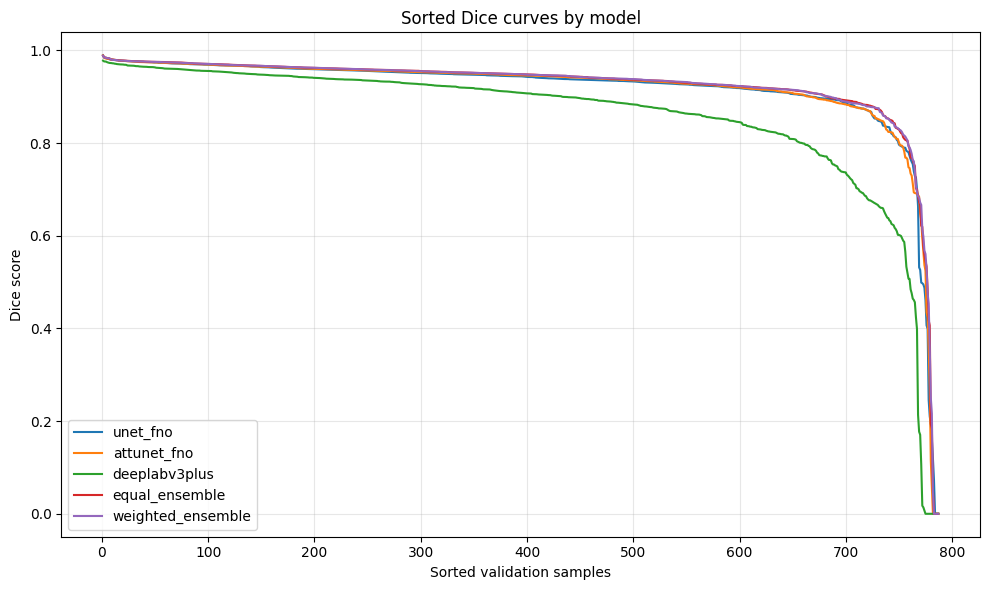

Elmentve: /content/drive/MyDrive/Brain MRI/ensemble_publication_results_final/curves/sorted_dice_curves.png


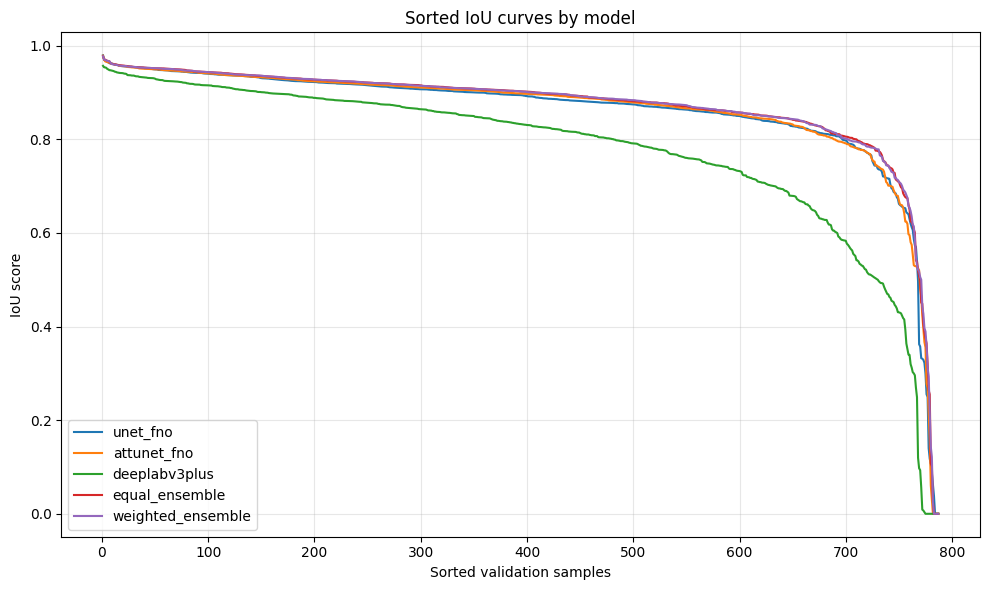

Elmentve: /content/drive/MyDrive/Brain MRI/ensemble_publication_results_final/curves/sorted_iou_curves.png


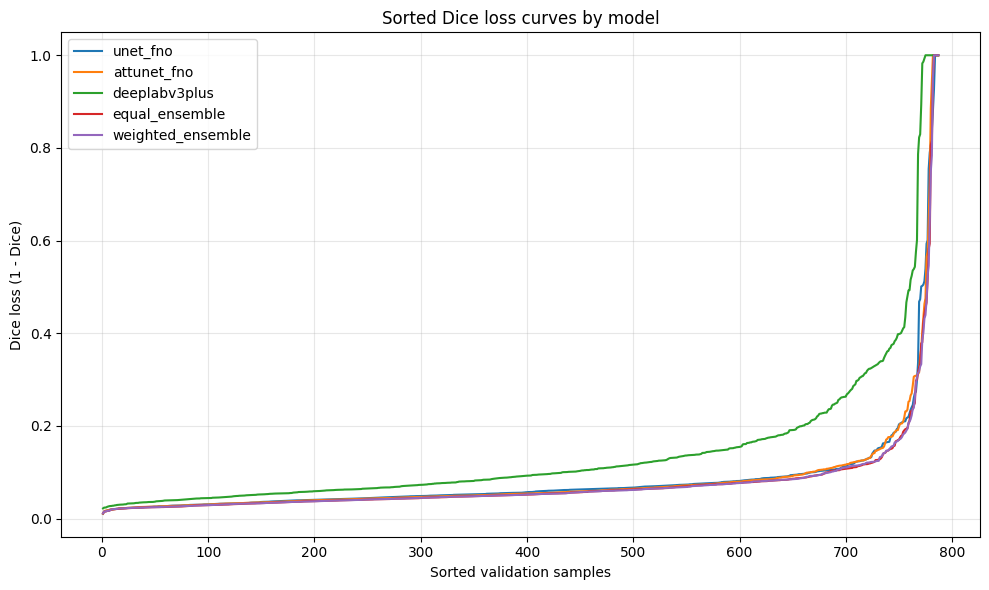

Elmentve: /content/drive/MyDrive/Brain MRI/ensemble_publication_results_final/curves/sorted_dice_loss_curves.png


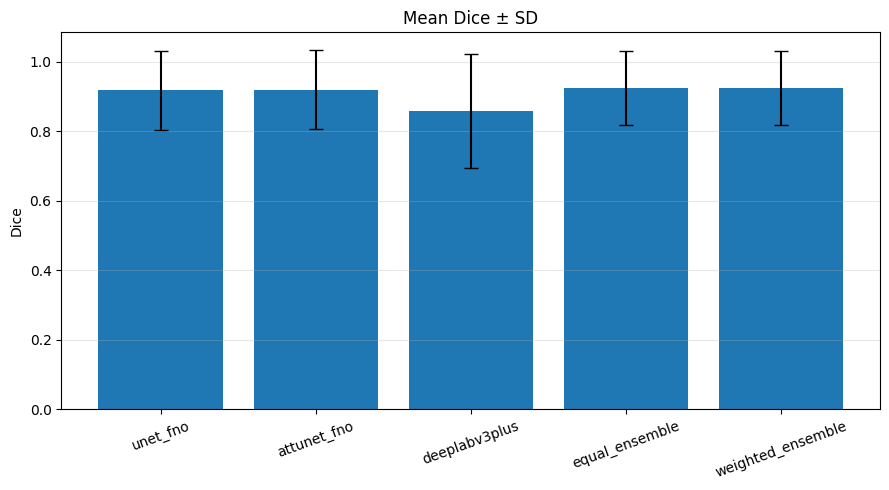

Elmentve: /content/drive/MyDrive/Brain MRI/ensemble_publication_results_final/curves/mean_dice_barplot.png


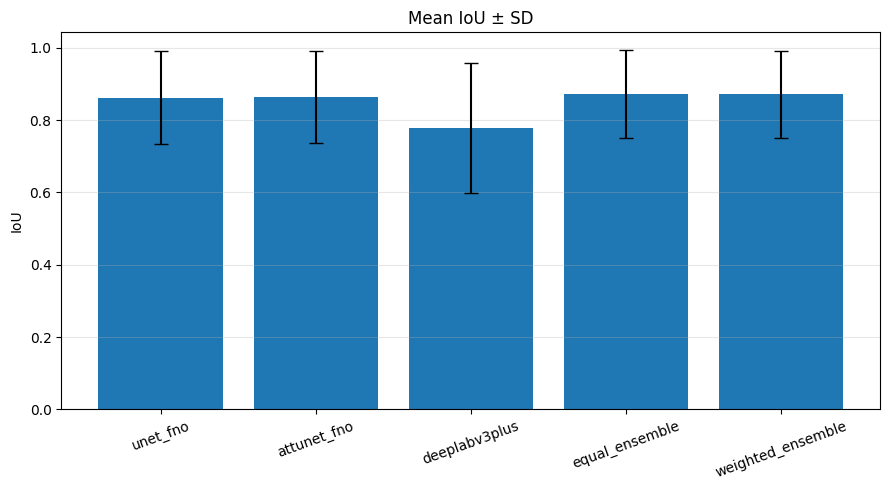

Elmentve: /content/drive/MyDrive/Brain MRI/ensemble_publication_results_final/curves/mean_iou_barplot.png
Elmentve: /content/drive/MyDrive/Brain MRI/ensemble_publication_results_final/curves/curve_summary_metrics.csv


In [ ]:

# 22) Publication-ready curves at the end

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

curves_dir = os.path.join(cfg.output_dir, "curves")
os.makedirs(curves_dir, exist_ok=True)

# Feltételezzük, hogy ezek már léteznek a notebookban:
# all_tables = {
#     'unet_fno': ...,
#     'attunet_fno': ...,
#     'deeplabv3plus': ...,
#     'equal_ensemble': ...,
#     'weighted_ensemble': ...
# }

model_order = ['unet_fno', 'attunet_fno', 'deeplabv3plus', 'equal_ensemble', 'weighted_ensemble']
available_models = [m for m in model_order if m in all_tables]

# -------------------------------------------------
# A) Sorted Dice curve
# -------------------------------------------------
plt.figure(figsize=(10, 6))

for model_name in available_models:
    df = all_tables[model_name].copy()
    vals = df['dice'].dropna().sort_values(ascending=False).reset_index(drop=True).values
    plt.plot(range(1, len(vals) + 1), vals, label=model_name)

plt.xlabel("Sorted validation samples")
plt.ylabel("Dice score")
plt.title("Sorted Dice curves by model")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

dice_curve_path = os.path.join(curves_dir, "sorted_dice_curves.png")
plt.savefig(dice_curve_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Elmentve: {dice_curve_path}")

# -------------------------------------------------
# B) Sorted IoU curve
# -------------------------------------------------
plt.figure(figsize=(10, 6))

for model_name in available_models:
    df = all_tables[model_name].copy()
    vals = df['iou'].dropna().sort_values(ascending=False).reset_index(drop=True).values
    plt.plot(range(1, len(vals) + 1), vals, label=model_name)

plt.xlabel("Sorted validation samples")
plt.ylabel("IoU score")
plt.title("Sorted IoU curves by model")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

iou_curve_path = os.path.join(curves_dir, "sorted_iou_curves.png")
plt.savefig(iou_curve_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Elmentve: {iou_curve_path}")

# -------------------------------------------------
# C) Dice loss curve (evaluation formában)
# Dice loss = 1 - Dice
# -------------------------------------------------
plt.figure(figsize=(10, 6))

for model_name in available_models:
    df = all_tables[model_name].copy()
    vals = (1.0 - df['dice'].dropna()).sort_values(ascending=True).reset_index(drop=True).values
    plt.plot(range(1, len(vals) + 1), vals, label=model_name)

plt.xlabel("Sorted validation samples")
plt.ylabel("Dice loss (1 - Dice)")
plt.title("Sorted Dice loss curves by model")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

dice_loss_curve_path = os.path.join(curves_dir, "sorted_dice_loss_curves.png")
plt.savefig(dice_loss_curve_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Elmentve: {dice_loss_curve_path}")

# -------------------------------------------------
# D) Mean ± std bar plot for Dice and IoU
# -------------------------------------------------
summary_plot_rows = []
for model_name in available_models:
    df = all_tables[model_name]
    summary_plot_rows.append({
        "model": model_name,
        "dice_mean": float(df["dice"].mean()),
        "dice_std": float(df["dice"].std(ddof=1)),
        "iou_mean": float(df["iou"].mean()),
        "iou_std": float(df["iou"].std(ddof=1)),
    })

summary_plot_df = pd.DataFrame(summary_plot_rows)

# Dice barplot
plt.figure(figsize=(9, 5))
plt.bar(summary_plot_df["model"], summary_plot_df["dice_mean"], yerr=summary_plot_df["dice_std"], capsize=5)
plt.ylabel("Dice")
plt.title("Mean Dice ± SD")
plt.xticks(rotation=20)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

dice_bar_path = os.path.join(curves_dir, "mean_dice_barplot.png")
plt.savefig(dice_bar_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Elmentve: {dice_bar_path}")

# IoU barplot
plt.figure(figsize=(9, 5))
plt.bar(summary_plot_df["model"], summary_plot_df["iou_mean"], yerr=summary_plot_df["iou_std"], capsize=5)
plt.ylabel("IoU")
plt.title("Mean IoU ± SD")
plt.xticks(rotation=20)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

iou_bar_path = os.path.join(curves_dir, "mean_iou_barplot.png")
plt.savefig(iou_bar_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Elmentve: {iou_bar_path}")

# -------------------------------------------------
# E) CSV mentés a görbékhez
# -------------------------------------------------
summary_plot_csv = os.path.join(curves_dir, "curve_summary_metrics.csv")
summary_plot_df.to_csv(summary_plot_csv, index=False)
print(f"Elmentve: {summary_plot_csv}")

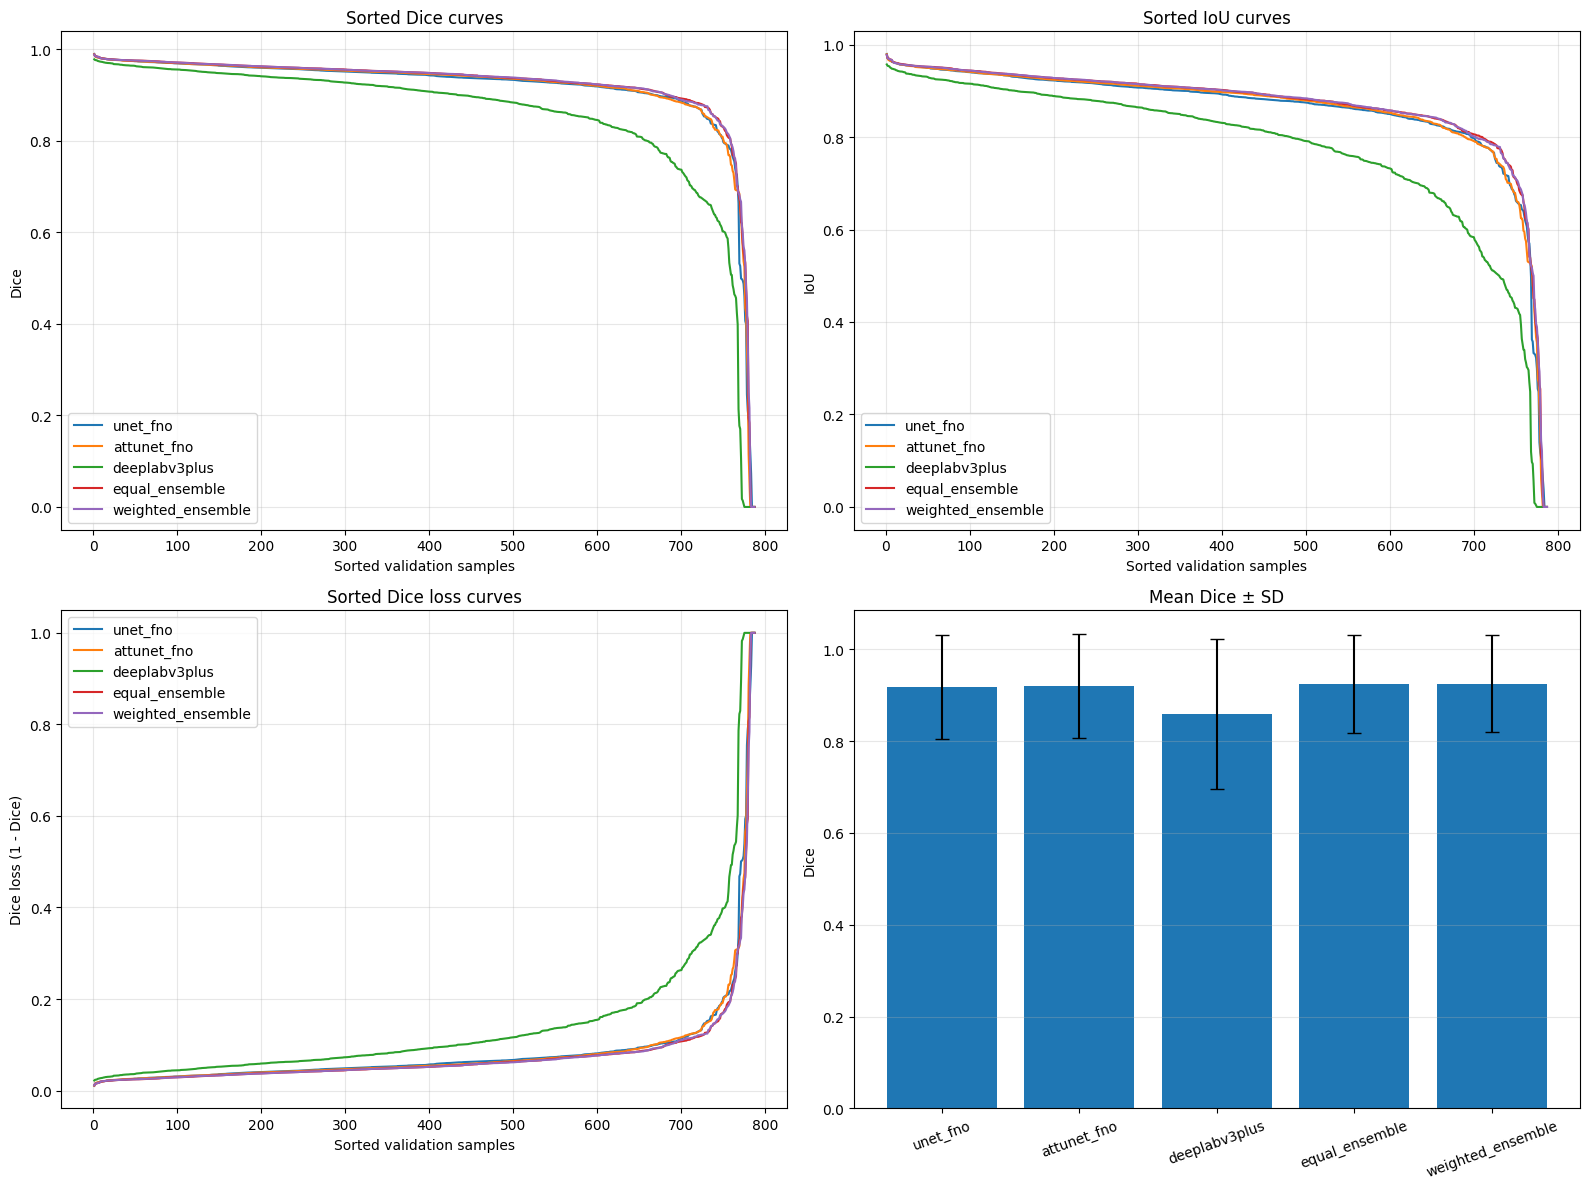

Elmentve: /content/drive/MyDrive/Brain MRI/ensemble_publication_results_final/curves/combined_publication_figure.png


In [ ]:
# =========================
# 23) Combined publication figure
# =========================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# A) Dice
for model_name in available_models:
    vals = all_tables[model_name]['dice'].dropna().sort_values(ascending=False).reset_index(drop=True).values
    axes[0, 0].plot(range(1, len(vals) + 1), vals, label=model_name)
axes[0, 0].set_title("Sorted Dice curves")
axes[0, 0].set_xlabel("Sorted validation samples")
axes[0, 0].set_ylabel("Dice")
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# B) IoU
for model_name in available_models:
    vals = all_tables[model_name]['iou'].dropna().sort_values(ascending=False).reset_index(drop=True).values
    axes[0, 1].plot(range(1, len(vals) + 1), vals, label=model_name)
axes[0, 1].set_title("Sorted IoU curves")
axes[0, 1].set_xlabel("Sorted validation samples")
axes[0, 1].set_ylabel("IoU")
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# C) Dice loss
for model_name in available_models:
    vals = (1.0 - all_tables[model_name]['dice'].dropna()).sort_values(ascending=True).reset_index(drop=True).values
    axes[1, 0].plot(range(1, len(vals) + 1), vals, label=model_name)
axes[1, 0].set_title("Sorted Dice loss curves")
axes[1, 0].set_xlabel("Sorted validation samples")
axes[1, 0].set_ylabel("Dice loss (1 - Dice)")
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# D) Mean Dice
axes[1, 1].bar(summary_plot_df["model"], summary_plot_df["dice_mean"], yerr=summary_plot_df["dice_std"], capsize=5)
axes[1, 1].set_title("Mean Dice ± SD")
axes[1, 1].set_ylabel("Dice")
axes[1, 1].tick_params(axis='x', rotation=20)
axes[1, 1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()

combined_fig_path = os.path.join(curves_dir, "combined_publication_figure.png")
plt.savefig(combined_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Elmentve: {combined_fig_path}")